# Preliminary analysis of the data from Ferritienda's inventory 

In [2]:
!which python

/Users/dianasolfonseca/Library/Caches/pypoetry/virtualenvs/ferriatienda-2HfN-FcT-py3.11/bin/python


In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import csv 

Infos regarding the data:
- The "referencia" column refers to the code for ferritienda's products internally 
- The "descripcion" column refers to the supplier's code for the product
- The brand for each product is the last word on the name of the product if not it is a generic product 


In [4]:
#We start by reading the csv file
data = pd.read_csv("../data/inventario_ferritienda.csv", sep=";", encoding="latin1")
data = data.drop(data.columns[[0, 1, 2, 3]], axis=1)
# Mettre à jour les noms des colonnes
data.columns = [
    "Nombre", 
    "Código del producto o servicio", 
    "Referencia", 
    "Unidad de medida", 
    "Categoría", 
    "Descripción", 
    "Costo inicial", 
    "Precio base", 
    "Impuesto", 
    "Precio total", 
    "Precio general", 
    "Precio lista general 2023", 
    "Código cuenta contable", 
    "Cuenta contable", 
    "Código cuenta de inventario", 
    "Cuenta de inventario", 
    "Código cuenta de costo de venta", 
    "Cuenta de costo de venta", 
    "Código de barras 2", 
    "Código de barras 3", 
    "Código de barras"
]
data = data.drop(columns=["Código del producto o servicio", "Precio lista general 2023", "Código de barras 2", 
    "Código de barras 3" ])
# print(data.head())
print("first row", data.iloc[0])

first row Nombre                             ABRAZADERA 10-00 TITAN 3/8"
Referencia                                                   4
Unidad de medida                                        Unidad
Categoría                                          TORNILLERIA
Descripción                                                NaN
Costo inicial                                       720,000000
Precio base                                        1008,000000
Impuesto                                                  19.0
Precio total                                              1200
Precio general                                     1008,000000
Código cuenta contable                                  413505
Cuenta contable                                         Ventas
Código cuenta de inventario                           143505.0
Cuenta de inventario                               Inventarios
Código cuenta de costo de venta                       613505.0
Cuenta de costo de venta                 Cost

In [5]:
print(data.describe())


         Impuesto  Código cuenta contable  Código cuenta de inventario  \
count  4932.00000                  5017.0                       4965.0   
mean     18.97283                413505.0                     143505.0   
std       0.60525                     0.0                          0.0   
min       5.00000                413505.0                     143505.0   
25%      19.00000                413505.0                     143505.0   
50%      19.00000                413505.0                     143505.0   
75%      19.00000                413505.0                     143505.0   
max      19.00000                413505.0                     143505.0   

       Código cuenta de costo de venta  
count                           4965.0  
mean                          613505.0  
std                                0.0  
min                           613505.0  
25%                           613505.0  
50%                           613505.0  
75%                           613505.0  
max  

In [6]:
#missing values
print(data.isnull().sum())

Nombre                                0
Referencia                           15
Unidad de medida                      0
Categoría                           132
Descripción                        2548
Costo inicial                         0
Precio base                           0
Impuesto                             85
Precio total                          0
Precio general                        0
Código cuenta contable                0
Cuenta contable                       0
Código cuenta de inventario          52
Cuenta de inventario                 52
Código cuenta de costo de venta      52
Cuenta de costo de venta             52
Código de barras                    146
dtype: int64


In [7]:
#where refrencia is null 
print(data[data["Referencia"].isnull()])

                                                 Nombre Referencia  \
84                                                LLAVE        NaN   
3769                  LAMPARA ANTIPOLVO 1.20 MT MERCURY        NaN   
3793                          BOMBILLO LED 30W SILVANIA        NaN   
3912                                      CABLE 1X1 3MT        NaN   
4036                        CERRADURA POMO ALCOBA FANAL        NaN   
4091                 CANDADO CROMADO/ DORADO LLAVE CRUZ        NaN   
4125  ANTICORROSIVO PROTECCION ICO BLANCO 1/2 GALON ...        NaN   
4148    Yoyo Para Guadaï¿½adora Manual Th109-10 Bellota        NaN   
4387                            MANTENIMIENTO DE EQUIPO        NaN   
4399                 PALUSTRE MANGO PLASTICO NO 5 UDUKE        NaN   
4410         GUANTE CAUCHO INDUSTRIAL PREMIUM GOYA T 10        NaN   
4435                             DESCUENTOS COMERCIALES        NaN   
4510                        CANCAMO CERRADO N 00 RANGER        NaN   
4814      CINTA AISL

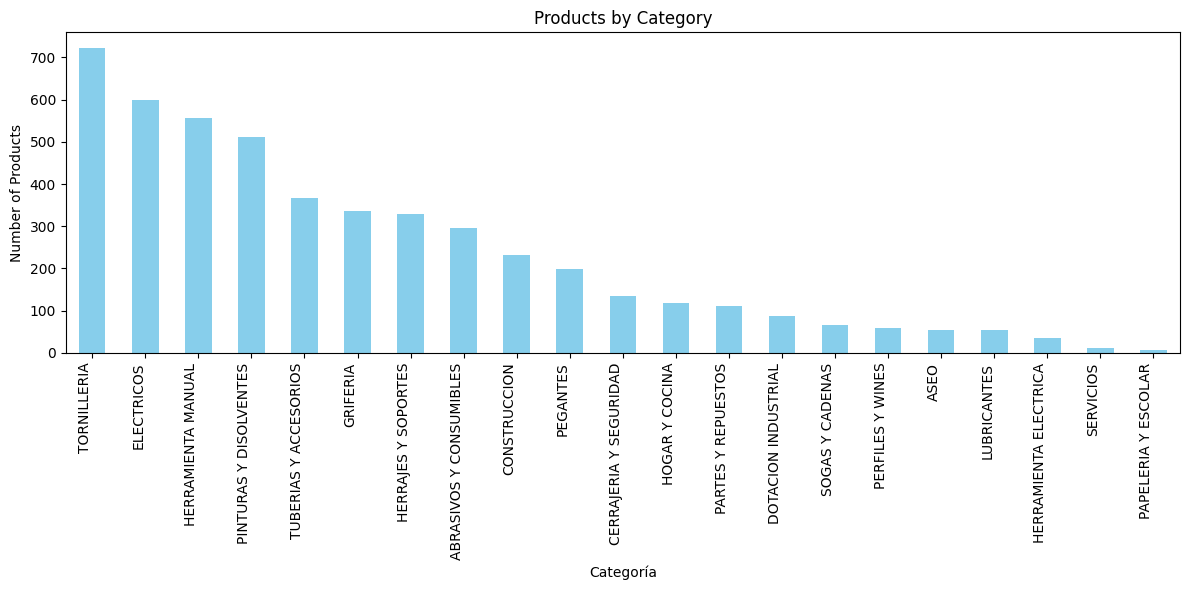

In [8]:
products_by_category = (
    data.groupby("Categoría")
    .size()
    .sort_values(ascending=False)
)


plt.figure(figsize=(12, 6))
products_by_category.plot(kind="bar", color="skyblue")
plt.title("Products by Category")
plt.xlabel("Categoría")
plt.ylabel("Number of Products")
plt.xticks(rotation=90, ha='right') 
plt.tight_layout()
plt.show()

In [9]:
# Categories with the most products
most_products = data["Categoría"].value_counts().head(10)
print(most_products)

Categoría
TORNILLERIA                723
ELECTRICOS                 599
HERRAMIENTA MANUAL         556
PINTURAS Y DISOLVENTES     511
TUBERIAS Y ACCESORIOS      367
GRIFERIA                   335
HERRAJES Y SOPORTES        330
ABRASIVOS Y CONSUMIBLES    295
CONSTRUCCION               233
PEGANTES                   198
Name: count, dtype: int64


In [10]:
#we are going to extract the brand for each product so that we can then go scrap all the information regarding the product on it's official website
#we extract the last word of the name of the product
data["Marca"] = data["Nombre"].str.split().str[-1]
brands = data["Marca"].unique()
for i in range(len(brands)):
    print(brands[i])

# plt.figure(figsize=(12, 6))
# brands.plot(kind="bar", color="skyblue")
# plt.title("Products by Brand")
# plt.xlabel("Marca")
# plt.ylabel("Number of Products")
# plt.xticks(rotation=90, ha='right')
# plt.tight_layout()


# print(data[["Nombre", "Marca"]].head())



3/8"
1/2"
TRUPER
1/2B
CRESCENT
UN
U
NEGRO
UNIDAD
PRETUL
39
GU10
ASTRO
MAXI
INCOLMA
TOOLS
GOYA
RANGER
HERMEX
SECURITY
17/8"
6
TESA
3M
1MT
PEQUEï¿½O
CODELCA
KONTIKI
DOC
11/2"
EXCALIBUR
ABRACOL
DEWALT
PREMIER
PORRAS
ESTANDAR
PEQUEï¿½AS
SUPER
8MT
OSBLACK/TITANIUM
BLANCO
FUELLE
L
8
9
PIEZAS
MERCURY
LLAVE
CORNETA
2.40MT
MM
P
ORIGINAL
X3"
3/4X1"
006
007
008
009
21/2
3
CORONA
GYD
5
GP
PINTE
AVE
STANLEY
GM
1M
CAJA
LOCTITE
UNIFER
ARCO
ENAR
LAVAMANOS
20G
750CC
BORDADA
LITEWAY
3/16X1/2"UN
5/32X1"UN
5/32X21/2"UN
1/2X2"UN
1/4X1"UN
1/4X11/2"UN
3/8X1"UN
5/16X11/4"UN
5/16X31/2"UN
7/16X11/2"UN
7/16X2"UN
8X1/2"50
8X1/2"DOC
50
COBRE
GRIVAL
11
12
X300MT
2.2MT
NICHOLSON
11/2
3/4"
1"
NAVIDEï¿½A
+CLAVO
CLAVO
10
16
20
24
28
36
4
44
52
60
72
88
7
FORTE
G
Oz
ML
CC
GALON
BOCHERINI
1/4"
ECO
GRIFOS
MULTIMARCA
COMPLETO
CUADRANTE
11/4"
2"
PAVCO
3/8
PLASGRIFOS
ONZ
RIOPLAST
CAPOTERA
PAï¿½O
BALON
PROCABLES
DESNUDO
5V
KILO
8V
1B
PEQUEï¿½A
TUPER
100
PAQUETE
30M
6MT
3MT
UDUKE
COAXIAL
5MT
LONA
LONAS
PALADA
MT
KLINTEK
RECICL

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5017 entries, 0 to 5016
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Nombre                           5017 non-null   object 
 1   Referencia                       5002 non-null   object 
 2   Unidad de medida                 5017 non-null   object 
 3   Categoría                        4885 non-null   object 
 4   Descripción                      2469 non-null   object 
 5   Costo inicial                    5017 non-null   object 
 6   Precio base                      5017 non-null   object 
 7   Impuesto                         4932 non-null   float64
 8   Precio total                     5017 non-null   object 
 9   Precio general                   5017 non-null   object 
 10  Código cuenta contable           5017 non-null   int64  
 11  Cuenta contable                  5017 non-null   object 
 12  Código cuenta de inv

We are going to get informations about each product using web scrapping and then we are going to analyze the data.

### Electricos category

We are going to get a sample from the truper products and specifically of products category (categoria ) "HERRAMIENTA ELECTRICA" and some from the category "HERRAMIENTA MANUAL" to get the information about the product using web scrapping 

In [12]:
truper_products = data[data["Marca"] == "TRUPER"].copy()
truper_products['Marca'] = truper_products['Marca'] + " " + truper_products['Descripción'].str.findall(r'\d+').str.join(" ")

#### WEB SCRAPPING "Mercado Libre" Site 

In [ ]:
column_names = [
    "Nombre", "Referencia", "Unidad de medida", "Categoría", "Descripción",
    "Costo inicial", "Precio base", "Impuesto", "Precio total", "Precio general",
    "Disponibilidad", "Marca", "Modelo", "Imagen URL", "Fecha scrapeo",
    "Proveedor", "Condición", "Ubicación", "Garantía", "Caracteristicas", "Descripcion"]

df = pd.read_csv(
    "./data/scraped_electric_truper_data.csv",
    sep=";",             
    quoting=csv.QUOTE_NONE,  
    encoding="utf-8",
    names=column_names, 
    header=0,
    on_bad_lines="skip",
    engine="python"   
)

print(df.head())
print(df.shape)

                                              Nombre  Referencia  \
0     DESTORNILLADOR INALAMBRICO BATERIA 3.6V TRUPER        3544   
1       LLANA LISA MANGO DE MADERA 6 REMACHES TRUPER        3926   
2  JUEGO DE 7 LLAVES TORX LARGAS CON ORGANIZADOR ...        1368   
3  "MANDRIL ZANCO 7/16"" PARA SIERRA COPA BIMETAL...        4010   
4           "PISTOLA DE SILICONA 4"" X 1/2"" TRUPER"        1849   

  Unidad de medida              Categoría Descripción Costo inicial  \
0           Unidad  HERRAMIENTA ELECTRICA       17033  57000,000000   
1           Unidad     HERRAMIENTA MANUAL       15406  11400,000000   
2           Unidad     HERRAMIENTA MANUAL       15553   9657,000000   
3           Unidad     HERRAMIENTA MANUAL       18123  14470,000000   
4           Unidad  HERRAMIENTA ELECTRICA       17536  19760,000000   

    Precio base  Impuesto Precio total Precio general  ...   Marca    Modelo  \
0  82353,000000      19.0        98000   82353,000000  ...  Ventas  143505.0   
1  1